# CPO vs PIDLag — wandb sweep `0e8xqg18`

Self-contained: pulls the sweep from wandb (cached to CSV on first run), then rebuilds every
figure. Re-running with the CSVs present does no network I/O.

**Sweep** `liam-paull/calibration_rl/0e8xqg18` — CPO and TRPOPID ("PIDLag") on
`SafetyPointGoal1-v0`, a 2x2x2x5 grid per algo:
`adv-estimation-method` x `update-iters` x `critic.lr` x 5 seeds = 40 runs each.

**Panels** (x = `TotalEnvSteps`, log): `Metrics/EpRet`, `Metrics/EpCost`,
`PooledMC/Correlation_r`, `PooledMC/Correlation_c`. Bands are +/- 1 s.e.m. across seeds.

**Rows** (when more than one) = the criterion used to pick each algo's config.

Needs `pip install jupyter ipykernel` in the `omnisafe` env to run interactively.

In [18]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ENTITY_PROJECT = "liam-paull/calibration_rl"
SWEEP_ID = "0e8xqg18"

# Anchor the cache to the repo, not to the working directory: running this notebook from
# the repo root must reuse the same CSVs, not silently re-download the sweep into whatever
# directory the kernel happened to start in.
_repo = pathlib.Path.cwd().resolve()
while not (_repo / "omnisafe").is_dir() and not (_repo / "plots").is_dir():
    if _repo.parent == _repo:
        raise RuntimeError("could not find the MICE repo root")
    _repo = _repo.parent
DATA_DIR = str(_repo / "figs" / "sweep_0e8xqg18")
os.makedirs(DATA_DIR, exist_ok=True)
print("repo:", _repo, "\ncache dir:", DATA_DIR)
RAW_CSV = os.path.join(DATA_DIR, "raw_runs.csv")
TS_CSV = os.path.join(DATA_DIR, "all_runs_timeseries.csv")

HISTORY_KEYS = ["TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost",
                "PooledMC/Correlation_r", "PooledMC/Correlation_c"]
CFG_KEYS = ["algo", "adv", "update_iters", "critic_lr"]

## 1. Data (cached)

In [19]:
def save_csv(df, path):
    """Write via a temp file + rename: an interrupted run cannot leave a half-written
    cache that the next run would silently treat as complete."""
    tmp = str(path) + ".tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


def to_numeric(df, cols):
    """Force `cols` to a numeric dtype.

    wandb's history() hands back a sparsely-logged column (the PooledMC correlations, only
    present at eval epochs) as dtype=object, while the same data round-tripped through CSV
    comes back float64.  Aggregating the object version string-concatenates the NaNs
    instead of averaging them, so a cold start would fail where a cached run succeeds.
    """
    for c in cols:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def fetch_summary():
    """One row per run: its config and end-of-training summary metrics."""
    import wandb
    api = wandb.Api(timeout=120)
    rows = []
    for r in api.sweep(f"{ENTITY_PROJECT}/{SWEEP_ID}").runs:
        c = r.config
        rows.append(dict(
            run_id=r.id, name=r.name, state=r.state,
            algo=c.get("algo"), adv=c.get("adv-estimation-method"),
            update_iters=c.get("algo-cfgs.update-iters"),
            critic_lr=c.get("model-cfgs.critic.lr"),
            critic_hidden=str(c.get("model-cfgs.critic.hidden-sizes")),
            cost_limit=c.get("cost-limit"), seed=c.get("seed"),
            EpRet=r.summary.get("Metrics/EpRet"),
            EpCost=r.summary.get("Metrics/EpCost"),
            TotalCost=r.summary.get("Metrics/TotalCost"),
            EpLen=r.summary.get("Metrics/EpLen"),
            TotalEnvSteps=r.summary.get("TotalEnvSteps"),
        ))
    return pd.DataFrame(rows)


def fetch_histories(raw):
    """Per-epoch history of every run, so any selection criterion can be plotted offline."""
    import wandb
    api = wandb.Api(timeout=180)
    out = []
    for i, r in raw.iterrows():
        h = api.run(f"{ENTITY_PROJECT}/{r.run_id}").history(keys=HISTORY_KEYS, samples=100000)
        for c in CFG_KEYS + ["seed", "run_id"]:
            h[c] = r[c]
        out.append(h)
        print(f"{i+1}/{len(raw)} {r.algo} {r.adv}/{r.update_iters}/{r.critic_lr:g} seed{r.seed}",
              flush=True)
    return pd.concat(out, ignore_index=True)


if os.path.exists(RAW_CSV):
    raw = pd.read_csv(RAW_CSV)
else:
    raw = fetch_summary()
    save_csv(raw, RAW_CSV)

if os.path.exists(TS_CSV):
    all_ts = pd.read_csv(TS_CSV)
else:
    all_ts = fetch_histories(raw)
    save_csv(all_ts, TS_CSV)

raw = to_numeric(raw, ["EpRet", "EpCost", "TotalCost", "EpLen", "TotalEnvSteps",
                       "seed", "update_iters", "critic_lr"])
all_ts = to_numeric(all_ts, HISTORY_KEYS)

X_MIN = all_ts["TotalEnvSteps"].min()
X_MAX = all_ts["TotalEnvSteps"].max()
print(f"{len(raw)} runs, {all_ts.shape[0]} history rows, steps {X_MIN:,.0f} -> {X_MAX:,.0f}")
raw.groupby(["algo", "adv", "update_iters", "critic_lr"]).size().rename("n_seeds").to_frame().T

80 runs, 40960 history rows, steps 20,000 -> 10,240,000


algo            CPO                                                  TRPOPID  \
adv             gae                       plain                          gae   
update_iters     2             10            2             10             2    
critic_lr    0.0001 0.0003 0.0001 0.0003 0.0001 0.0003 0.0001 0.0003  0.0001   
n_seeds           5      5      5      5      5      5      5      5       5   

algo                                                           
adv                                plain                       
update_iters            10            2             10         
critic_lr    0.0003 0.0001 0.0003 0.0001 0.0003 0.0001 0.0003  
n_seeds           5      5      5      5      5      5      5

## 2. Style

Reverse-engineered from `figs/cpo_vs_pidlag_plot.png`: Okabe-Ito series colors, y-grid only,
left+bottom spines, DejaVu Sans, direct series labels instead of a legend.

In [20]:
BLUE, ORANGE = "#0072B2", "#D55E00"       # Okabe-Ito
INK, MUTED = "#1a1a1a", "#5a5a5a"         # title ink / label ink
SPINE, TICK, GRID = "#909090", "#8a8a8a", "#d8d8d8"
BAND_ALPHA, LW, MS = 0.18, 2.2, 5
FS_TITLE, FS_LABEL, FS_TICK, FS_SERIES, FS_NOTE, FS_ROW = 28, 23, 17, 23, 15.5, 22

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "axes.titlesize": FS_TITLE, "axes.titlecolor": INK, "axes.titlepad": 8,
    "axes.labelsize": FS_LABEL, "axes.labelcolor": MUTED,
    "axes.edgecolor": SPINE, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "xtick.labelsize": FS_TICK, "ytick.labelsize": FS_TICK,
    "xtick.color": TICK, "ytick.color": TICK,
    "xtick.labelcolor": MUTED, "ytick.labelcolor": MUTED,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 3.6, "ytick.major.size": 3.6,
    "xtick.major.width": 1.0, "ytick.major.width": 1.0,
    "xtick.minor.visible": False, "ytick.minor.visible": False,
})

ALGOS = [("CPO", "CPO", BLUE), ("TRPOPID", "PIDLag", ORANGE)]
COST_LIMIT = 10
XTICKS = [3e4, 1e5, 3e5, 1e6, 3e6, 1e7]
PANELS = [
    ("Episode Return", "Metrics/EpRet", False, None),
    ("Episode Cost", "Metrics/EpCost", False, None),
    ("Correlation (reward)", "PooledMC/Correlation_r", True, (0, 1)),
    ("Correlation (cost)", "PooledMC/Correlation_c", True, (0, 1)),
]


def _fmt(v, _):
    return f"{v/1e6:g}M" if v >= 1e6 else f"{v/1e3:g}k"

## 3. Picking a config

For each algo, score every config by aggregating its 5 seeds, then take the winner.

| criterion | score | best |
|---|---|---|
| `ratio` | per-seed `EpRet / TotalCost`, averaged over seeds | max |
| `EpRet` | mean final `Metrics/EpRet` | max |
| `TotalCost` | mean `Metrics/TotalCost` over the whole run | min |

`variant` restricts the candidate pool to one `adv-estimation-method` (`"any"` searches all).

In [21]:
CRITERIA = {
    "ratio":     dict(row_label="best by\nEpRet / TotalCost", mode="max"),
    "EpRet":     dict(row_label="best by\nEpRet",             mode="max"),
    "TotalCost": dict(row_label="best by\nTotalCost",         mode="min"),
}


def score_configs(variant="any"):
    cand = raw if variant == "any" else raw[raw.adv == variant]
    cand = cand.assign(ratio=cand.EpRet / cand.TotalCost)
    return (cand.groupby(CFG_KEYS)
            .agg(ratio=("ratio", "mean"), ratio_sem=("ratio", "sem"),
                 EpRet=("EpRet", "mean"), TotalCost=("TotalCost", "mean"),
                 n_seeds=("seed", "size"))
            .reset_index())


def best_configs(criterion, variant="any"):
    g = score_configs(variant)
    pick = g.groupby("algo")[criterion]
    idx = pick.idxmax() if CRITERIA[criterion]["mode"] == "max" else pick.idxmin()
    return g.loc[idx].set_index("algo")


def selected_ts(best, algo):
    row = best.loc[algo]
    return all_ts[(all_ts.algo == algo)
                  & (all_ts.adv == row.adv)
                  & (all_ts.update_iters == row.update_iters)
                  & np.isclose(all_ts.critic_lr, row.critic_lr)]


def aggregate(sub, col):
    """mean and s.e.m. across seeds at each logged TotalEnvSteps."""
    g = (sub.dropna(subset=[col]).groupby("TotalEnvSteps")[col]
         .agg(["mean", "std", "count"]).reset_index().sort_values("TotalEnvSteps"))
    g["sem"] = g["std"] / np.sqrt(g["count"])
    return g

## 4. The plot

In [22]:
# panel geometry in inches -- keeps every panel the same size whatever the row count
AX_W, AX_H, WGAP, HGAP = 4.80, 4.08, 0.97, 1.42
MARGIN_R, MARGIN_T, MARGIN_B, YLAB_W, ROWLAB_W = 0.06, 0.51, 0.85, 0.55, 1.15


def label_series(fig, ax, best, x_pad=1.35, right_pad_px=8):
    """Label each curve at its end, in the clear margin to the right of the last sample.

    Labels are drawn entirely beyond X_MAX -- where no curve or band exists -- and the x-axis
    is then widened until the widest one fits, so nothing ever lands on top of the data.
    """
    ends = sorted((aggregate(selected_ts(best, a), "Metrics/EpRet")["mean"].iloc[-1], lbl, c)
                  for a, lbl, c in ALGOS)

    lo, hi = ax.get_ylim()
    span = hi - lo
    gap = 0.11 * span                       # keep the two apart when the curves converge
    if ends[1][0] - ends[0][0] < gap:
        mid = 0.5 * (ends[0][0] + ends[1][0])
        ends = [(mid - gap / 2,) + ends[0][1:], (mid + gap / 2,) + ends[1][1:]]
    ends = [(min(max(y, lo + 0.05 * span), hi - 0.05 * span), lbl, c) for y, lbl, c in ends]

    ax.set_xlim(right=X_MAX * x_pad * 1.05)  # start tight; the loop below grows it as needed
    texts = [ax.text(X_MAX * x_pad, y, lbl, color=c, fontsize=FS_SERIES,
                     fontweight="bold", ha="left", va="center") for y, lbl, c in ends]

    for _ in range(8):                       # widen until the widest label clears the spine
        fig.canvas.draw()
        box = ax.get_window_extent()
        over = max(t.get_window_extent().x1 for t in texts) - (box.x1 - right_pad_px)
        if over <= 0:
            break
        x_lo, x_hi = ax.get_xlim()
        dex_per_px = np.log10(x_hi / x_lo) / box.width
        ax.set_xlim(right=x_hi * 10 ** (over * dex_per_px * 1.10))
    return ends


def plot_grid(criteria=("ratio",), variant="any", out=None, label_pad=1.35):
    """Build the panel grid.

    label_pad -- how far past the last sample the CPO/PIDLag labels sit, as a multiple of
    X_MAX (1.0 = flush against the curve end, larger = more clearance). The x-axis is then
    widened to fit them, so raising it widens the gap rather than pushing labels off-axes.
    """
    criteria = list(criteria)
    nrow = len(criteria)
    left = YLAB_W + (ROWLAB_W if nrow > 1 else 0.0)
    fig_w = left + 4 * AX_W + 3 * WGAP + MARGIN_R
    fig_h = MARGIN_T + nrow * AX_H + (nrow - 1) * HGAP + MARGIN_B

    fig, axes = plt.subplots(nrow, 4, figsize=(fig_w, fig_h), squeeze=False)
    fig.subplots_adjust(left=left / fig_w, right=1 - MARGIN_R / fig_w,
                        top=1 - MARGIN_T / fig_h, bottom=MARGIN_B / fig_h,
                        wspace=WGAP / AX_W, hspace=HGAP / AX_H)

    for r, crit in enumerate(criteria):
        best = best_configs(crit, variant)
        for c, (title, col, marker, ylim) in enumerate(PANELS):
            ax = axes[r][c]
            for algo, label, color in ALGOS:
                g = aggregate(selected_ts(best, algo), col)
                x, m, s = g["TotalEnvSteps"], g["mean"], g["sem"]
                ax.plot(x, m, color=color, linewidth=LW, zorder=3,
                        marker="o" if marker else None, markersize=MS, markeredgewidth=0)
                ax.fill_between(x, m - s, m + s, color=color, alpha=BAND_ALPHA,
                                linewidth=0, zorder=2)

            ax.set_xscale("log")
            ax.set_xlim(left=X_MIN)          # no left margin: start on the first sample
            ax.set_xticks(XTICKS)
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(_fmt))
            ax.xaxis.set_minor_locator(mticker.NullLocator())
            if ylim:
                ax.set_ylim(*ylim)
            if r == 0:
                ax.set_title(title)
            if r == nrow - 1:
                ax.set_xlabel("Total env steps")

            if col == "Metrics/EpCost":      # cost-limit rule + note
                ax.axhline(COST_LIMIT, color=MUTED, linewidth=1.7,
                           linestyle=(0, (5, 3)), zorder=4)
                lo, hi = ax.get_ylim()
                ax.text(3e6, COST_LIMIT + 0.19 * (hi - lo), "cost limit", fontsize=FS_NOTE,
                        style="italic", color=MUTED, ha="center", va="center")

        # direct series labels, in place of a legend
        label_series(fig, axes[r][0], best, x_pad=label_pad)

        if nrow > 1:                          # rotated row label naming the criterion
            pos = axes[r][0].get_position()
            fig.text(pos.x0 - (ROWLAB_W - 0.25) / fig_w, 0.5 * (pos.y0 + pos.y1),
                     CRITERIA[crit]["row_label"], fontsize=FS_ROW, fontweight="bold",
                     color=INK, ha="center", va="center", rotation=90, linespacing=1.4)

    if out:
        fig.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0.1, facecolor="white")
        print("saved:", out)
    return fig

## 5. Figures

### Single row — best config by `EpRet / TotalCost`

saved: ./cpo_vs_pidlag_sweep0e8xqg18.png


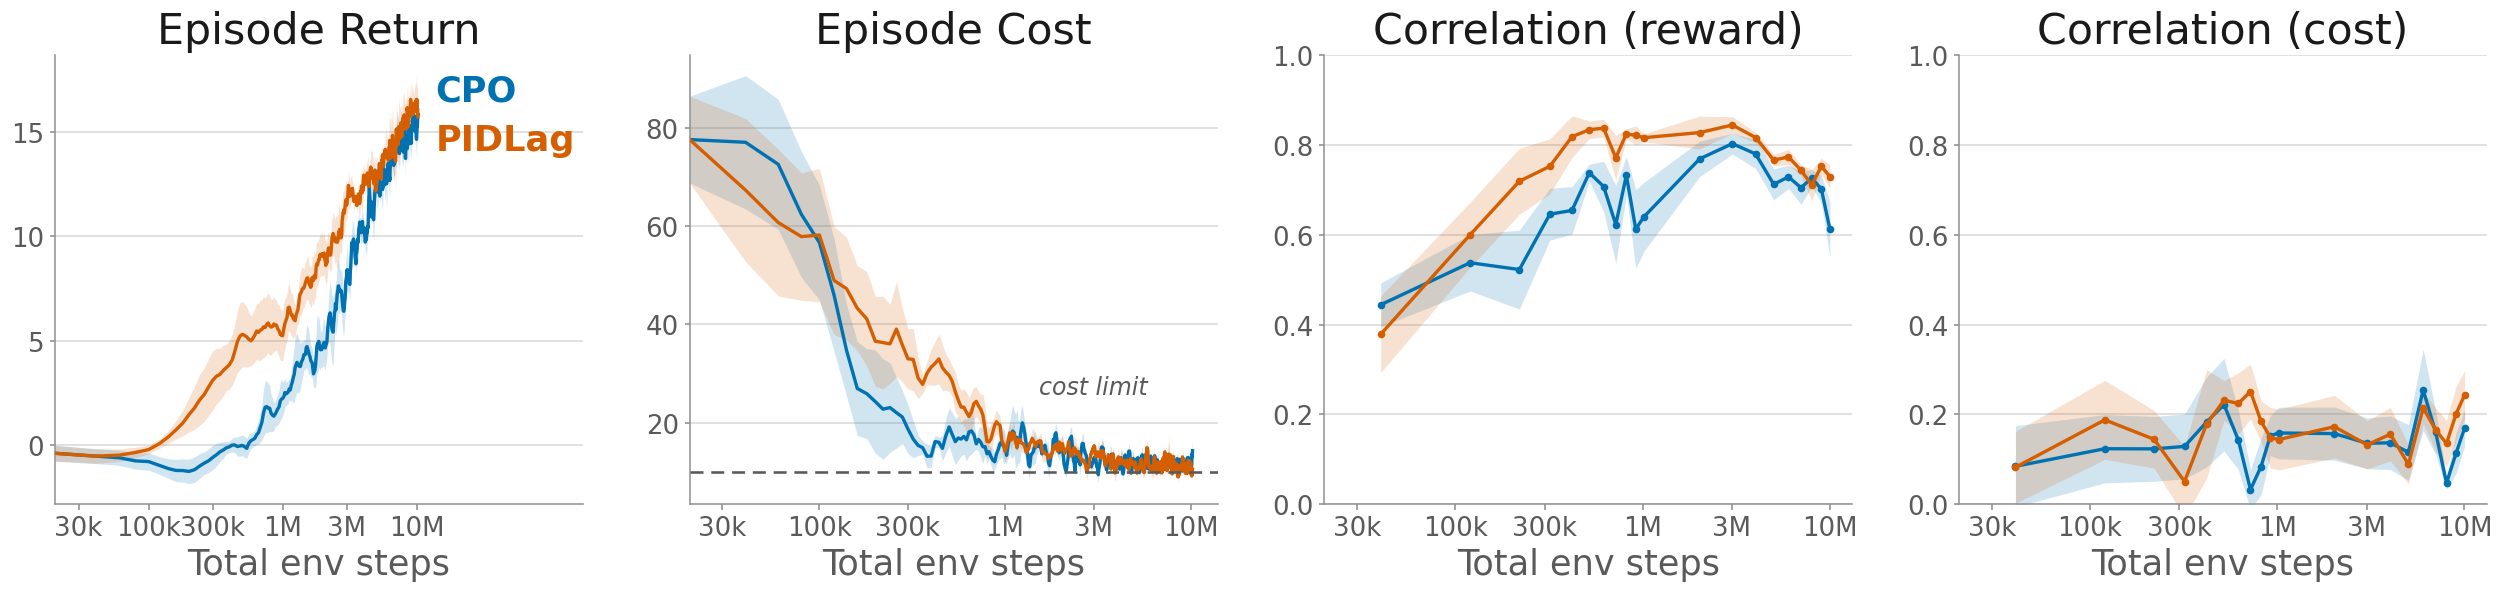

In [23]:
plot_grid(("ratio",), "any", f"{DATA_DIR}/cpo_vs_pidlag_sweep0e8xqg18.png");

### Single row — candidates restricted to `adv=gae`

saved: ./cpo_vs_pidlag_sweep0e8xqg18_gae.png


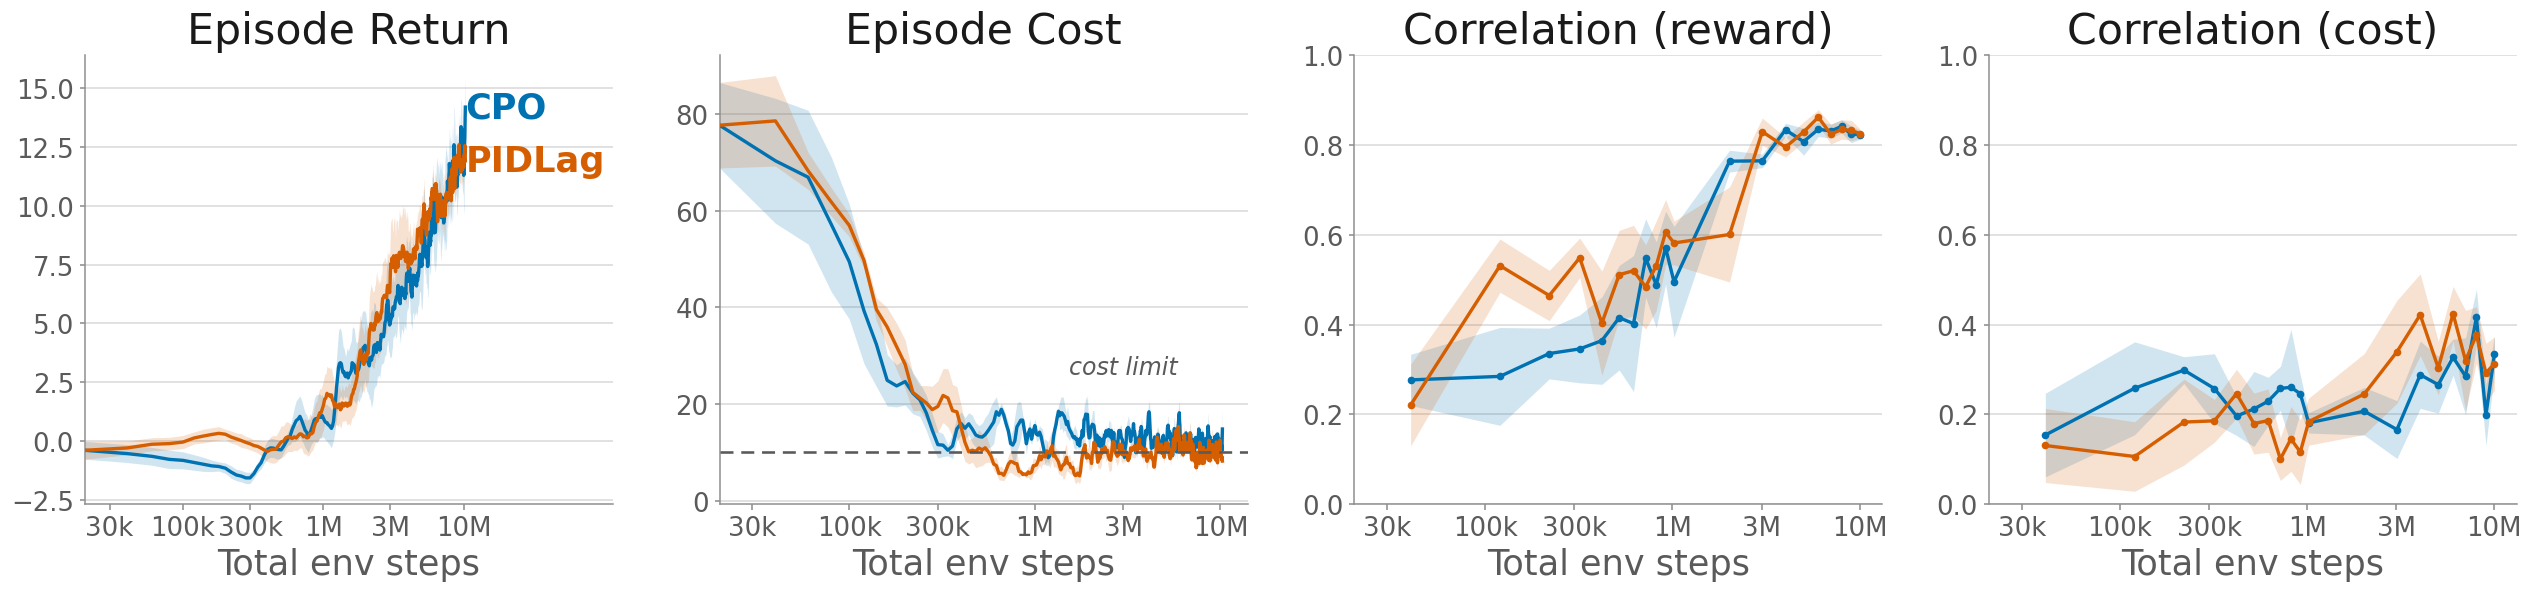

In [25]:
plot_grid(("ratio",), "gae", f"{DATA_DIR}/cpo_vs_pidlag_sweep0e8xqg18_gae.png", label_pad=1.0);

### Three rows — one per selection criterion

saved: ./cpo_vs_pidlag_sweep0e8xqg18_bycriterion.png


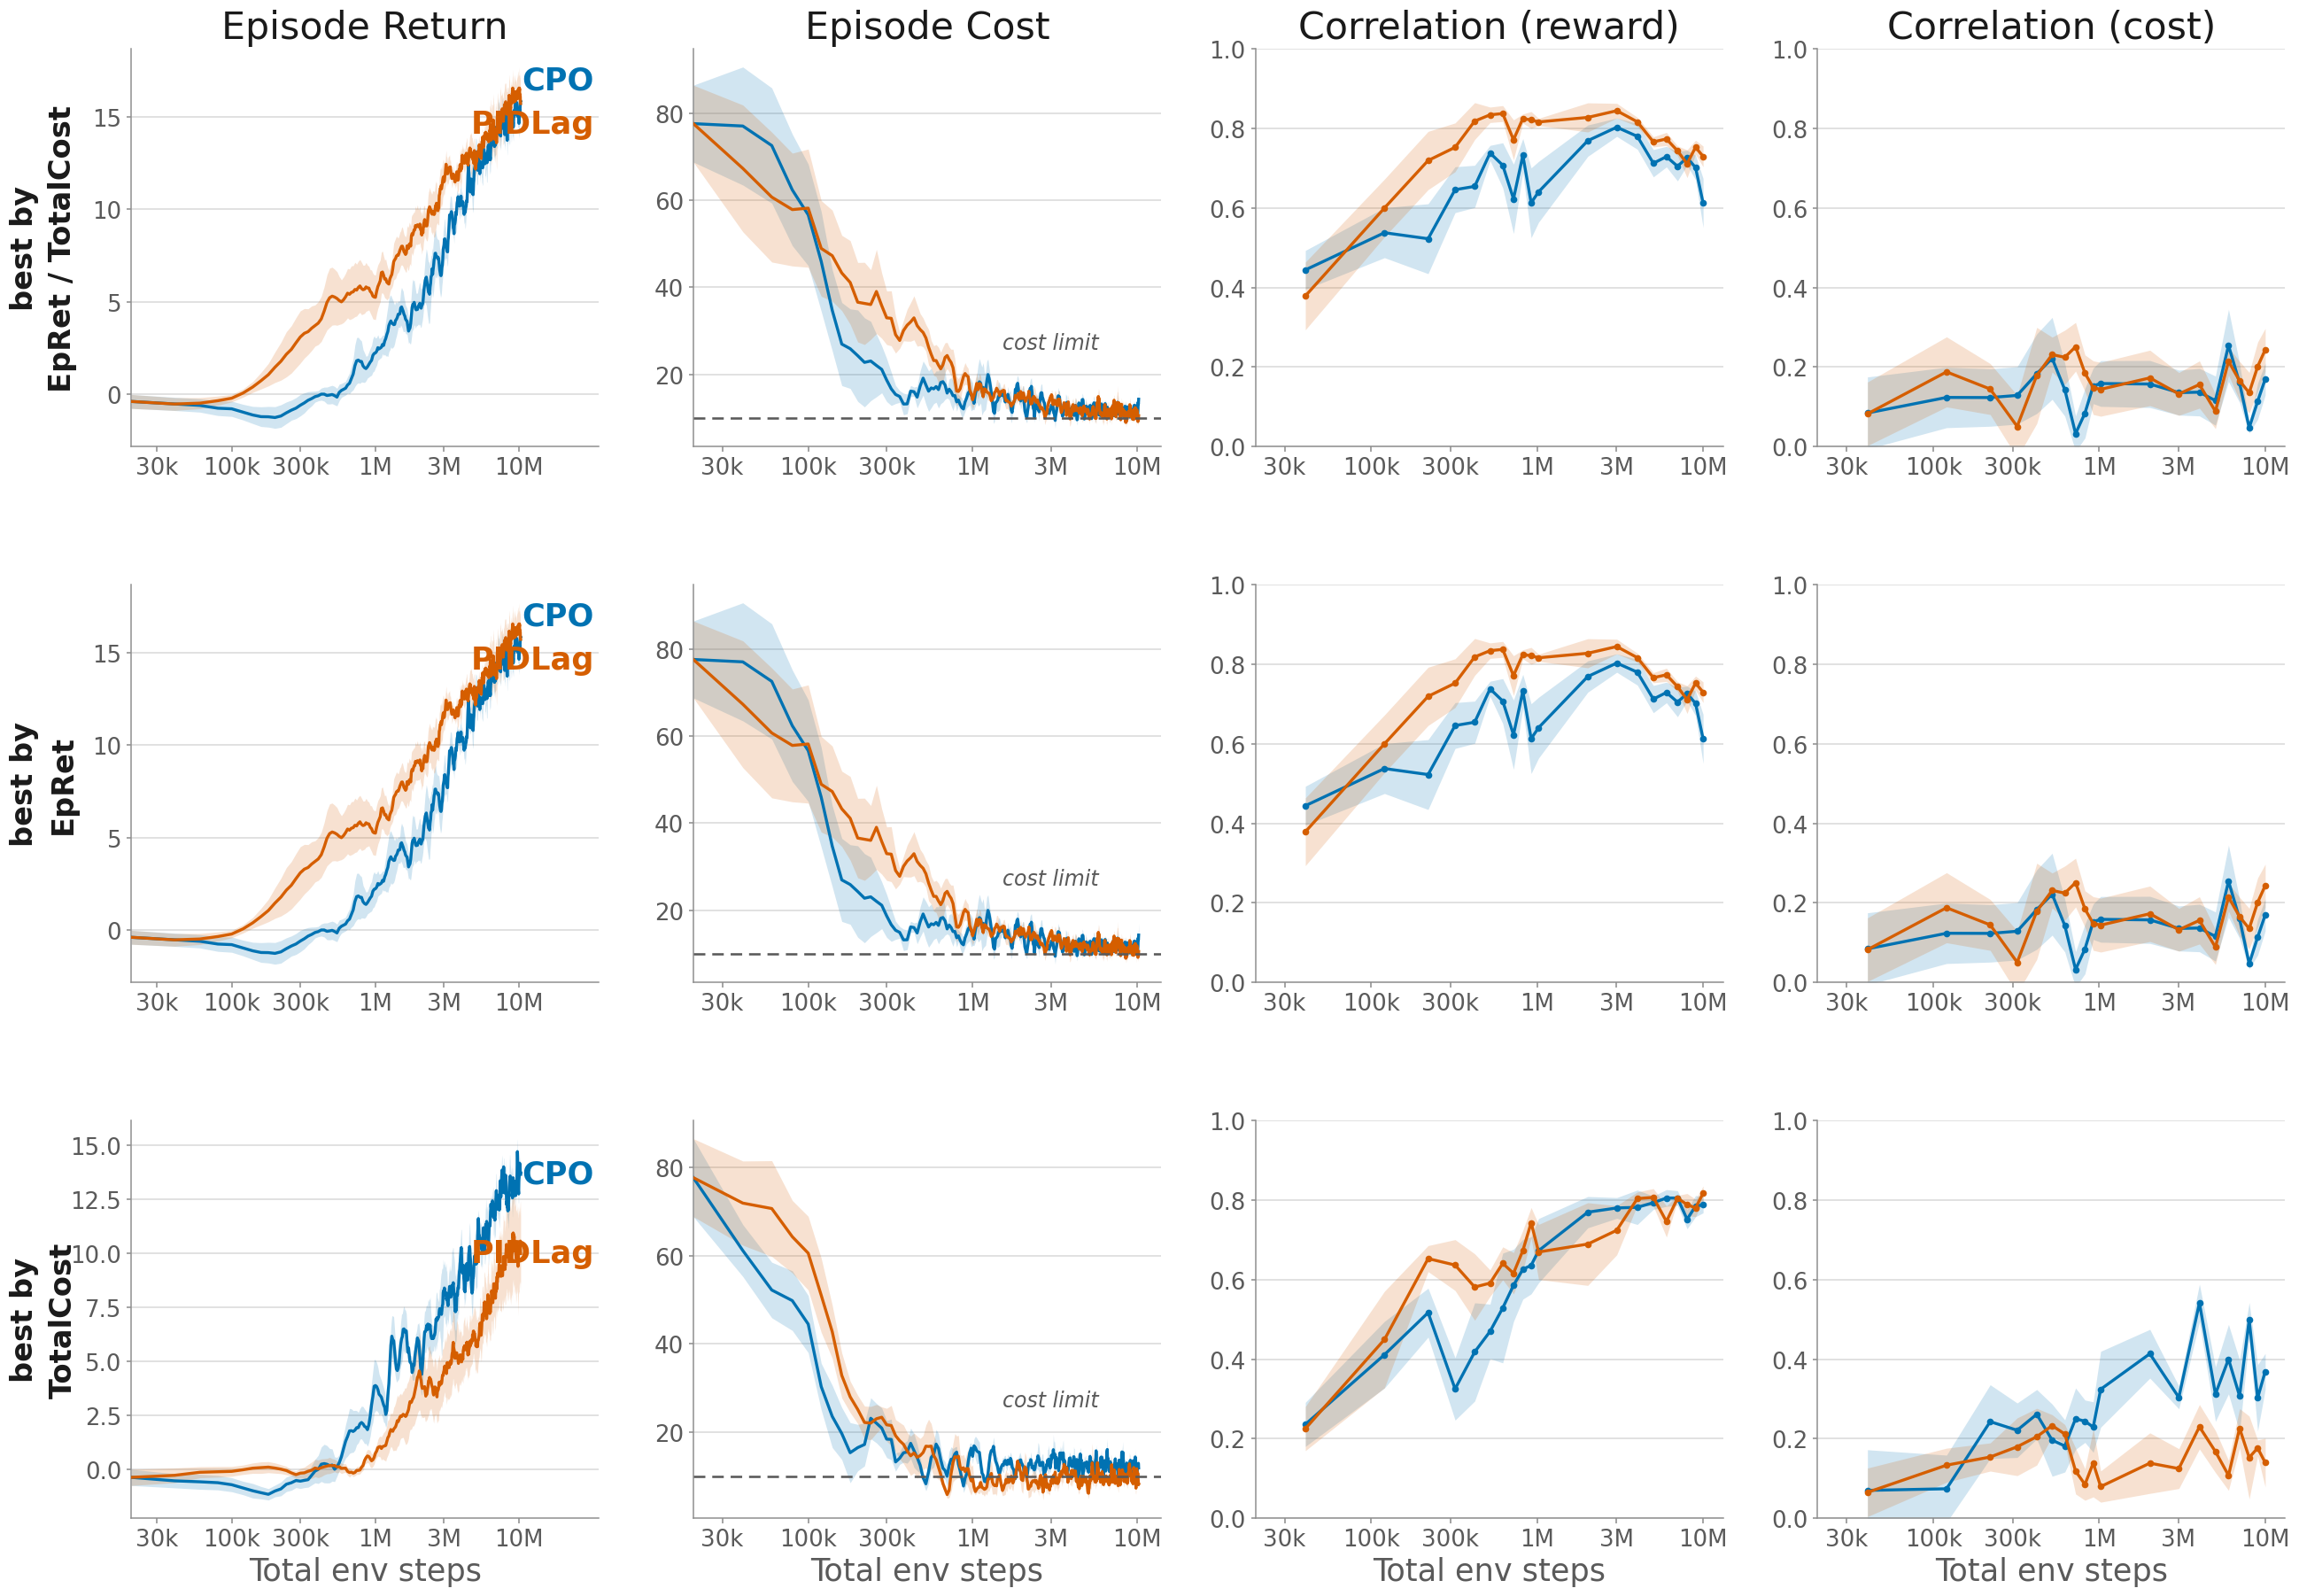

In [8]:
plot_grid(("ratio", "EpRet", "TotalCost"), "any",
          f"{DATA_DIR}/cpo_vs_pidlag_sweep0e8xqg18_bycriterion.png");

### Three rows — `adv=gae` only

saved: ./cpo_vs_pidlag_sweep0e8xqg18_gae_bycriterion.png


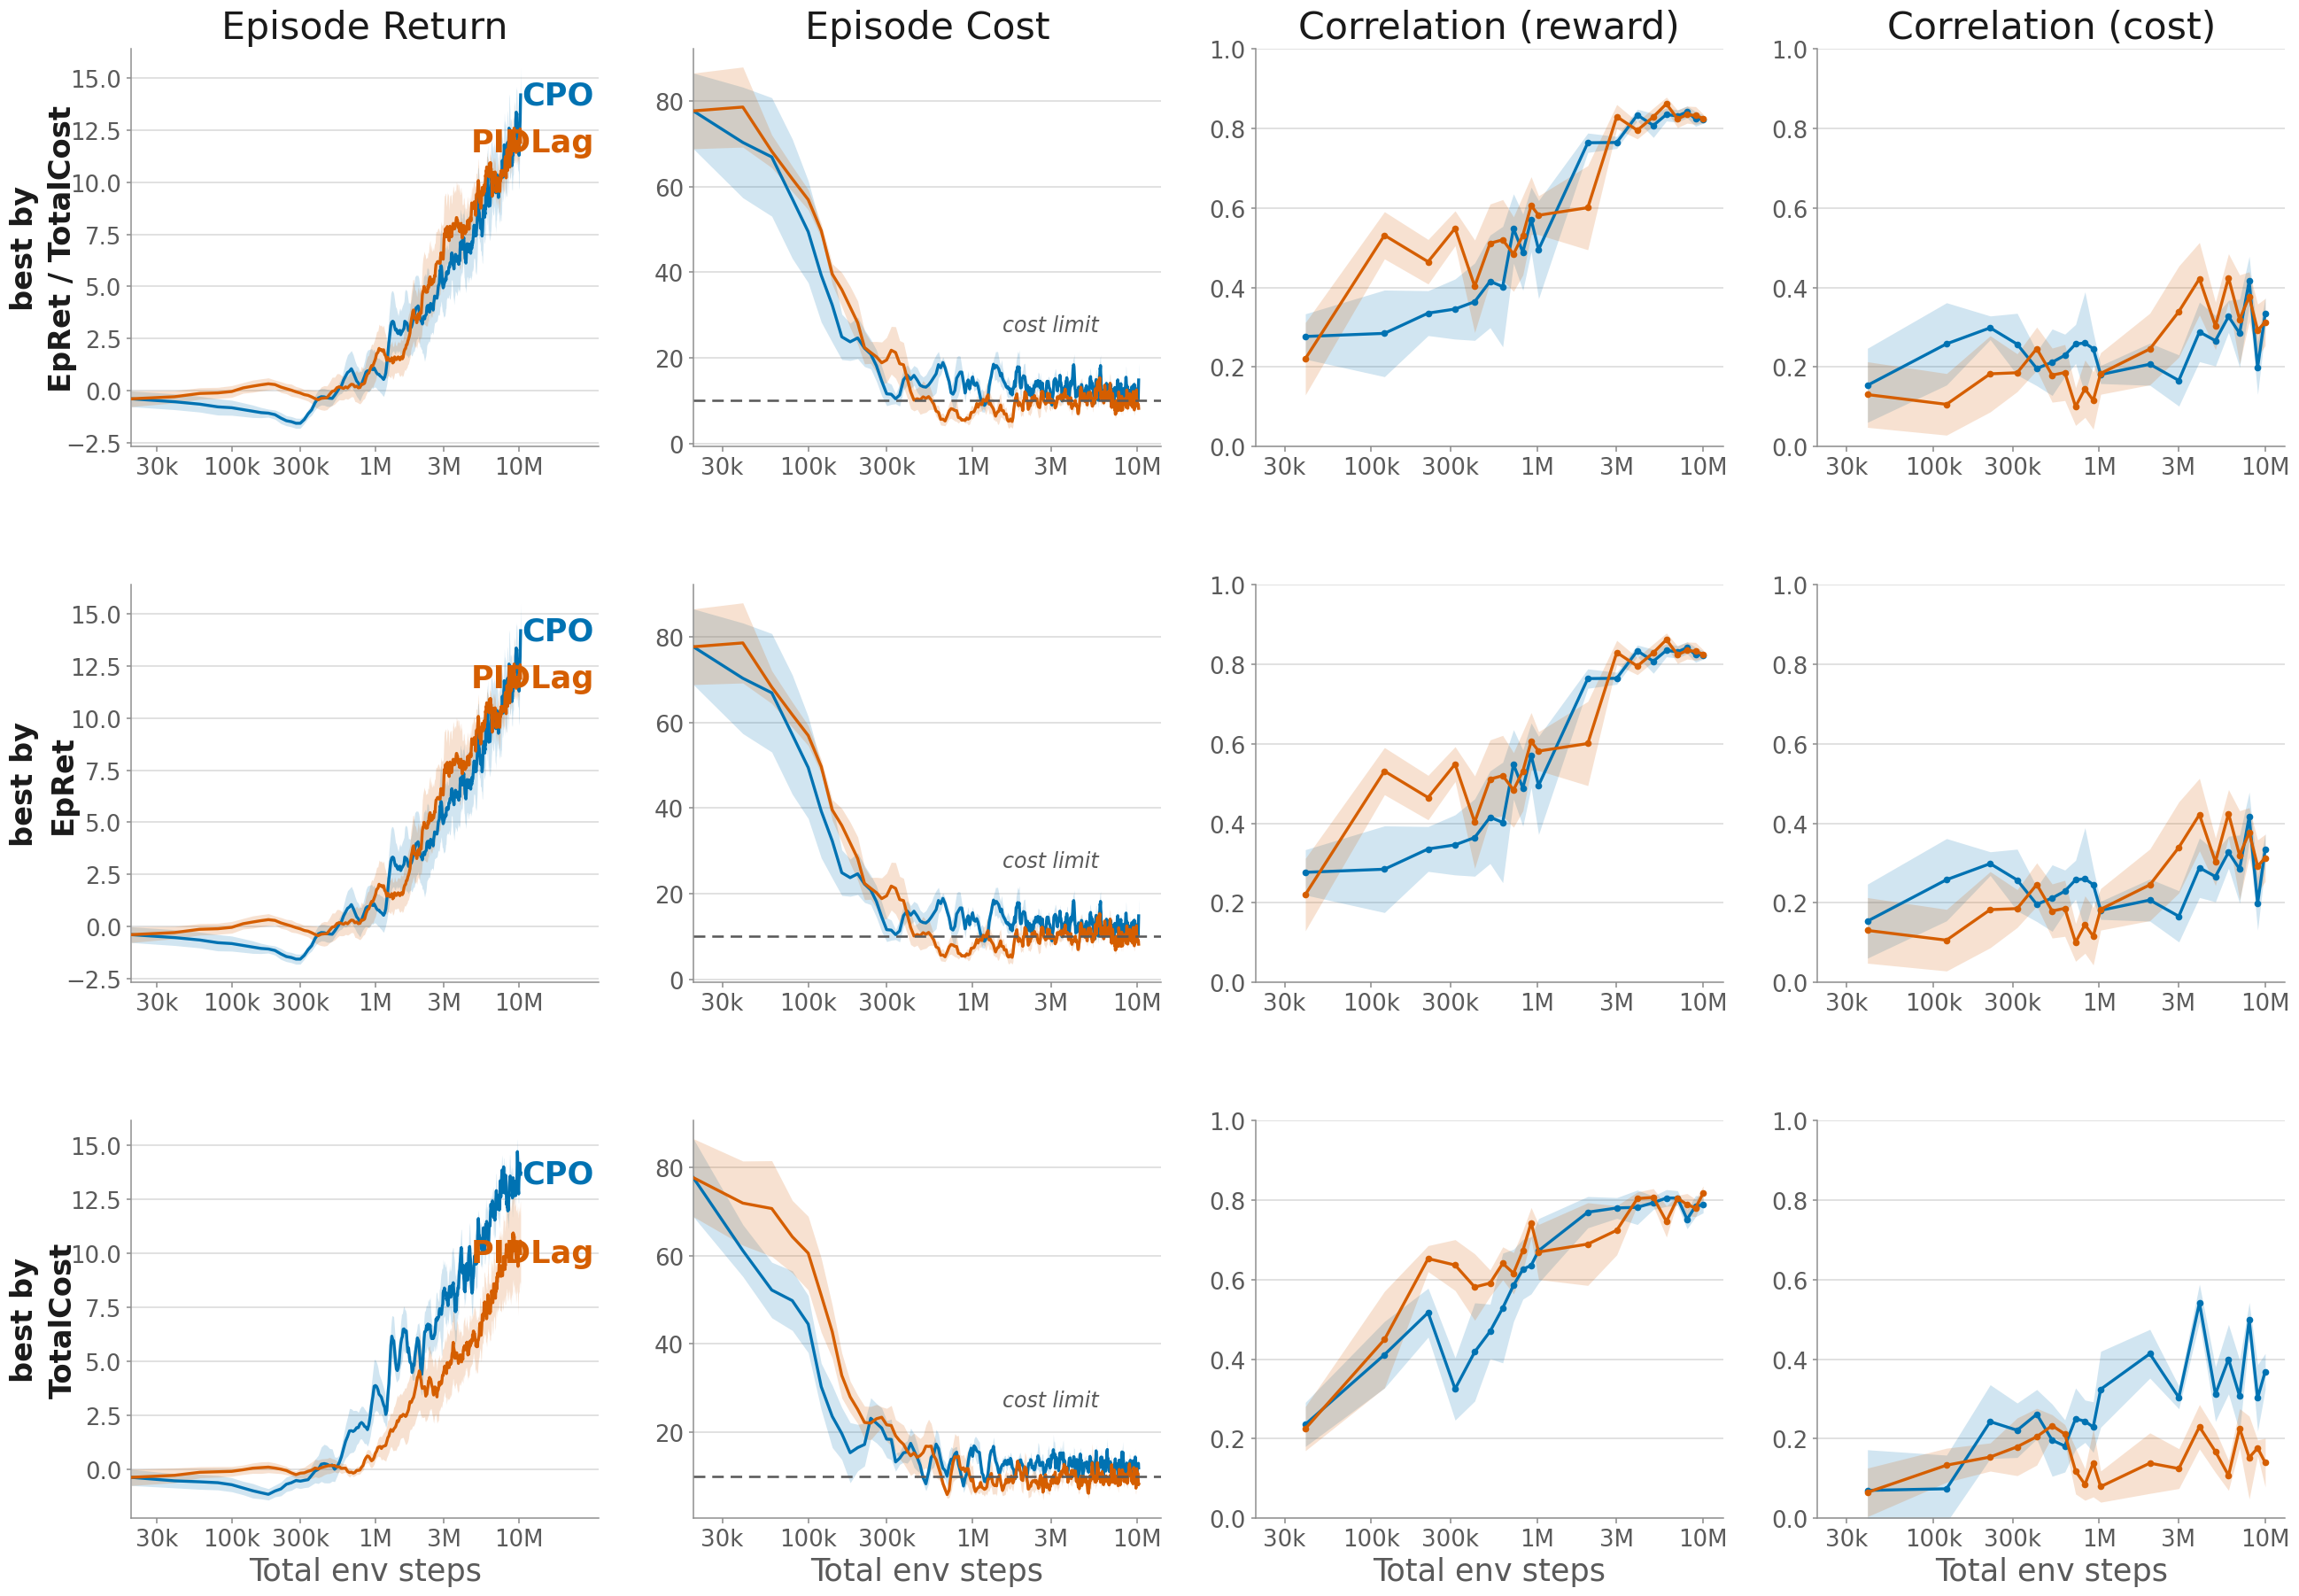

In [9]:
plot_grid(("ratio", "EpRet", "TotalCost"), "gae",
          f"{DATA_DIR}/cpo_vs_pidlag_sweep0e8xqg18_gae_bycriterion.png");

### Which config each criterion picked

In [ ]:
rows = []
for variant in ["any", "gae"]:
    for crit in CRITERIA:
        b = best_configs(crit, variant)
        for algo in b.index:
            r = b.loc[algo]
            rows.append(dict(variant=variant, criterion=crit, algo=algo, adv=r.adv,
                             update_iters=int(r.update_iters), critic_lr=r.critic_lr,
                             ratio=r.ratio, EpRet=r.EpRet, TotalCost=r.TotalCost))
pd.DataFrame(rows)